# Incongruent visual evaluation

This notebook tests whether the trained Refiner uses sample-specific visual evidence. The baseline posterior and reference remain unchanged while all three visual context tensors are replaced by contexts from another utterance.

The test uses length-grouped batches, a derangement with no self-pairs, multiple permutation seeds, target-length crop/pad, and paired utterance bootstrap. The dataset does not expose a verified speaker identity through the current pipeline, so this notebook does not make a same-speaker claim.


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch
from torchmetrics.text import WordErrorRate
from tqdm.auto import tqdm

PROJECT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), "..")
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from srcs.datasets.vicocktail import load_vicocktail
from srcs.nets.backend.ctc import ctc_decode
from srcs.nets.e2e import get_model
from srcs.spm.spm_train import ensure_unigram
from srcs.spm.text_transofm import TextTransform
from srcs.trainer.utils import (
    create_dataloader,
    load_config,
    move_batch,
    set_seed,
    update_wer,
)

CONFIG_PATH = os.path.join(PROJECT_ROOT, "config.yaml")
VSR_CHECKPOINT = os.path.join(
    PROJECT_ROOT, "checkpoints", "finetune_vsr_12", "final", "model.safetensors"
)
REFINER_CHECKPOINT = os.path.join(
    PROJECT_ROOT, "checkpoints", "refiner", "best.pt"
)
VISUAL_KEYS = ("visual_features", "h2_features", "h4_features")
MISMATCH_SEEDS = (11, 23, 37, 53, 71)
BOOTSTRAP_SAMPLES = 10000
BATCH_SIZE = 8

config = load_config(CONFIG_PATH)
seed = config["training"]["seed"]
set_seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = config["evaluation"].get("amp", True) and device.type == "cuda"

test_dataset = load_vicocktail(
    test_fraction=1.0, splits=("test",), seed=seed
)["test"]
model_path, units_path = ensure_unigram()
text_transform = TextTransform(model_path, units_path)

evaluation_config = config["evaluation"].copy()
evaluation_config["batch_size"] = BATCH_SIZE
evaluation_config["seed"] = seed
test_loader = create_dataloader(
    test_dataset, text_transform, "test", evaluation_config, shuffle=True
)

base_model = get_model(
    "auto-vsr", text_transform.vocab_size, checkpoint=VSR_CHECKPOINT
).to(device).eval()
refiner = get_model(
    "refiner",
    text_transform.vocab_size,
    checkpoint=REFINER_CHECKPOINT,
    blank_id=text_transform.blank_id,
    ignore_id=text_transform.ignore_id,
).to(device).eval()

print(f"Device: {device}")
print(f"Test samples: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")
print(f"Mismatch seeds: {MISMATCH_SEEDS}")


d:\projects\VietnameseVSR\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Test samples: 1167
Test batches: 146
Mismatch seeds: (11, 23, 37, 53, 71)


In [2]:
def make_derangement(batch_size, generator, device):
    if batch_size < 2:
        raise RuntimeError(
            "Incongruent evaluation requires at least two samples per batch."
        )

    shift = int(torch.randint(1, batch_size, (), generator=generator))
    permutation = torch.roll(torch.arange(batch_size), shifts=shift)
    return permutation.to(device)


def make_incongruent_contexts(visual_contexts, permutation):
    target_lengths = visual_contexts["input_lengths"]
    donor_lengths = target_lengths.index_select(0, permutation)
    target_length_values = target_lengths.detach().cpu().tolist()
    donor_length_values = donor_lengths.detach().cpu().tolist()
    donor_indices = permutation.detach().cpu().tolist()
    incongruent = visual_contexts.copy()

    for key in VISUAL_KEYS:
        source = visual_contexts[key]
        transformed = torch.zeros_like(source)

        for target_index, donor_index in enumerate(donor_indices):
            copy_length = min(
                target_length_values[target_index], donor_length_values[target_index]
            )
            transformed[target_index, :copy_length] = source[
                donor_index, :copy_length
            ]

        incongruent[key] = transformed

    return incongruent, donor_lengths


def decode_outputs(outputs):
    token_ids = ctc_decode(
        outputs["logits"], outputs["input_lengths"], text_transform.blank_id
    )
    return [text_transform.decode(item) for item in token_ids]


def decode_references(batch):
    labels = batch["labels"].detach().cpu()
    lengths = batch["label_lengths"].detach().cpu().tolist()
    return [
        text_transform.decode(label[:length])
        for label, length in zip(labels, lengths)
    ]


def word_error_count(reference, hypothesis):
    reference_words = reference.split()
    hypothesis_words = hypothesis.split()
    previous = list(range(len(hypothesis_words) + 1))

    for row, reference_word in enumerate(reference_words, start=1):
        current = [row]
        for column, hypothesis_word in enumerate(hypothesis_words, start=1):
            substitution = previous[column - 1] + int(
                reference_word != hypothesis_word
            )
            deletion = previous[column] + 1
            insertion = current[column - 1] + 1
            current.append(min(substitution, deletion, insertion))
        previous = current

    return previous[-1], len(reference_words)


def append_word_errors(target, references, hypotheses):
    for reference, hypothesis in zip(references, hypotheses):
        errors, _ = word_error_count(reference, hypothesis)
        target.append(errors)


def paired_bootstrap(
    correct_errors, incongruent_errors, reference_lengths, seed, samples=10000
):
    correct_errors = torch.as_tensor(correct_errors, dtype=torch.float64)
    incongruent_errors = torch.as_tensor(incongruent_errors, dtype=torch.float64)
    reference_lengths = torch.as_tensor(reference_lengths, dtype=torch.float64)
    sample_count = reference_lengths.numel()
    generator = torch.Generator().manual_seed(seed)
    differences = []
    chunk_size = 256

    for start in range(0, samples, chunk_size):
        size = min(chunk_size, samples - start)
        indices = torch.randint(
            sample_count, (size, sample_count), generator=generator
        )
        denominators = reference_lengths[indices].sum(dim=1).clamp_min(1.0)
        difference = (
            incongruent_errors[indices].sum(dim=1)
            - correct_errors[indices].sum(dim=1)
        ) / denominators
        differences.append(100.0 * difference)

    differences = torch.cat(differences)
    observed = 100.0 * (incongruent_errors.sum() - correct_errors.sum()) / (
        reference_lengths.sum().clamp_min(1.0)
    )
    lower, upper = torch.quantile(
        differences, torch.tensor([0.025, 0.975], dtype=differences.dtype)
    )
    return observed.item(), lower.item(), upper.item()


In [3]:
baseline_wer = WordErrorRate()
correct_wer = WordErrorRate()
incongruent_wer = {seed: WordErrorRate() for seed in MISMATCH_SEEDS}
permutation_generators = {
    seed: torch.Generator().manual_seed(seed) for seed in MISMATCH_SEEDS
}
correct_errors = []
incongruent_errors = {seed: [] for seed in MISMATCH_SEEDS}
reference_lengths = []
length_differences = {seed: [] for seed in MISMATCH_SEEDS}
fixed_points = {seed: 0 for seed in MISMATCH_SEEDS}
sample_count = 0

progress = tqdm(test_loader, desc="Incongruent evaluation")
for batch in progress:
    batch = move_batch(batch, device)
    batch_size = batch["videos"].size(0)

    with torch.inference_mode(), torch.autocast(
        device_type=device.type, dtype=torch.float16, enabled=amp_enabled
    ):
        baseline_logits, visual_contexts = base_model.get_contexts(
            batch["videos"], batch["video_lengths"]
        )
        correct_outputs = refiner(baseline_logits, visual_contexts)

    baseline_outputs = {
        "logits": baseline_logits,
        "input_lengths": visual_contexts["input_lengths"],
    }
    update_wer(baseline_wer, baseline_outputs, batch, text_transform)
    update_wer(correct_wer, correct_outputs, batch, text_transform)

    references = decode_references(batch)
    correct_hypotheses = decode_outputs(correct_outputs)
    append_word_errors(correct_errors, references, correct_hypotheses)
    reference_lengths.extend(len(reference.split()) for reference in references)

    for mismatch_seed in MISMATCH_SEEDS:
        permutation = make_derangement(
            batch_size, permutation_generators[mismatch_seed], device
        )
        fixed_points[mismatch_seed] += int(
            permutation.eq(torch.arange(batch_size, device=device)).sum()
        )
        incongruent_contexts, donor_lengths = make_incongruent_contexts(
            visual_contexts, permutation
        )
        differences = (
            visual_contexts["input_lengths"] - donor_lengths
        ).abs()
        length_differences[mismatch_seed].extend(
            differences.detach().cpu().tolist()
        )

        with torch.inference_mode(), torch.autocast(
            device_type=device.type, dtype=torch.float16, enabled=amp_enabled
        ):
            incongruent_outputs = refiner(baseline_logits, incongruent_contexts)

        update_wer(
            incongruent_wer[mismatch_seed],
            incongruent_outputs,
            batch,
            text_transform,
        )
        incongruent_hypotheses = decode_outputs(incongruent_outputs)
        append_word_errors(
            incongruent_errors[mismatch_seed],
            references,
            incongruent_hypotheses,
        )

    sample_count += batch_size
    progress.set_postfix(samples=sample_count)

baseline_wer_value = 100.0 * baseline_wer.compute().item()
correct_wer_value = 100.0 * correct_wer.compute().item()
incongruent_wer_values = {
    seed: 100.0 * metric.compute().item()
    for seed, metric in incongruent_wer.items()
}

print(f"Evaluated samples: {sample_count}")
print(f"Baseline WER: {baseline_wer_value:.3f}%")
print(f"Correct visual WER: {correct_wer_value:.3f}%")


Incongruent evaluation: 100%|██████████| 146/146 [01:18<00:00,  1.85it/s, samples=1167]

Evaluated samples: 1167
Baseline WER: 48.174%
Correct visual WER: 47.104%


In [4]:
bootstrap_results = {}
for mismatch_seed in MISMATCH_SEEDS:
    bootstrap_results[mismatch_seed] = paired_bootstrap(
        correct_errors,
        incongruent_errors[mismatch_seed],
        reference_lengths,
        seed=1000 + mismatch_seed,
        samples=BOOTSTRAP_SAMPLES,
    )

mean_incongruent_errors = torch.tensor(
    [incongruent_errors[seed] for seed in MISMATCH_SEEDS], dtype=torch.float64
).mean(dim=0)
mean_bootstrap = paired_bootstrap(
    correct_errors,
    mean_incongruent_errors,
    reference_lengths,
    seed=2026,
    samples=BOOTSTRAP_SAMPLES,
)
wer_tensor = torch.tensor(list(incongruent_wer_values.values()))
mean_incongruent_wer = wer_tensor.mean().item()
std_incongruent_wer = wer_tensor.std().item()

print("Positive delta means that incongruent visual is worse.")
print("Seed | WER (%) | Delta | 95% paired bootstrap CI | Mean length diff | Max | Fixed")
for mismatch_seed in MISMATCH_SEEDS:
    observed, lower, upper = bootstrap_results[mismatch_seed]
    differences = torch.tensor(length_differences[mismatch_seed], dtype=torch.float32)
    print(
        f"{mismatch_seed:>4} | {incongruent_wer_values[mismatch_seed]:>7.3f} | "
        f"{observed:>+6.3f} | [{lower:+.3f}, {upper:+.3f}] | "
        f"{differences.mean().item():>16.2f} | "
        f"{int(differences.max().item()):>3} | {fixed_points[mismatch_seed]}"
    )

mean_observed, mean_lower, mean_upper = mean_bootstrap
print(
    f"Mean incongruent WER: {mean_incongruent_wer:.3f}% "
    f"+/- {std_incongruent_wer:.3f}% across seeds"
)
print(
    f"Mean mismatch delta: {mean_observed:+.3f} WER points, "
    f"95% CI [{mean_lower:+.3f}, {mean_upper:+.3f}]"
)


Positive delta means that incongruent visual is worse.
Seed | WER (%) | Delta | 95% paired bootstrap CI | Mean length diff | Max | Fixed
  11 |  50.490 | +3.386 | [+3.019, +3.751] |             4.60 |  23 | 0
  23 |  50.743 | +3.639 | [+3.276, +3.999] |             4.45 |  23 | 0
  37 |  50.487 | +3.383 | [+3.023, +3.738] |             4.57 |  23 | 0
  53 |  50.440 | +3.337 | [+2.976, +3.688] |             4.53 |  22 | 0
  71 |  50.344 | +3.240 | [+2.883, +3.593] |             4.50 |  22 | 0
Mean incongruent WER: 50.501% +/- 0.148% across seeds
Mean mismatch delta: +3.397 WER points, 95% CI [+3.105, +3.683]


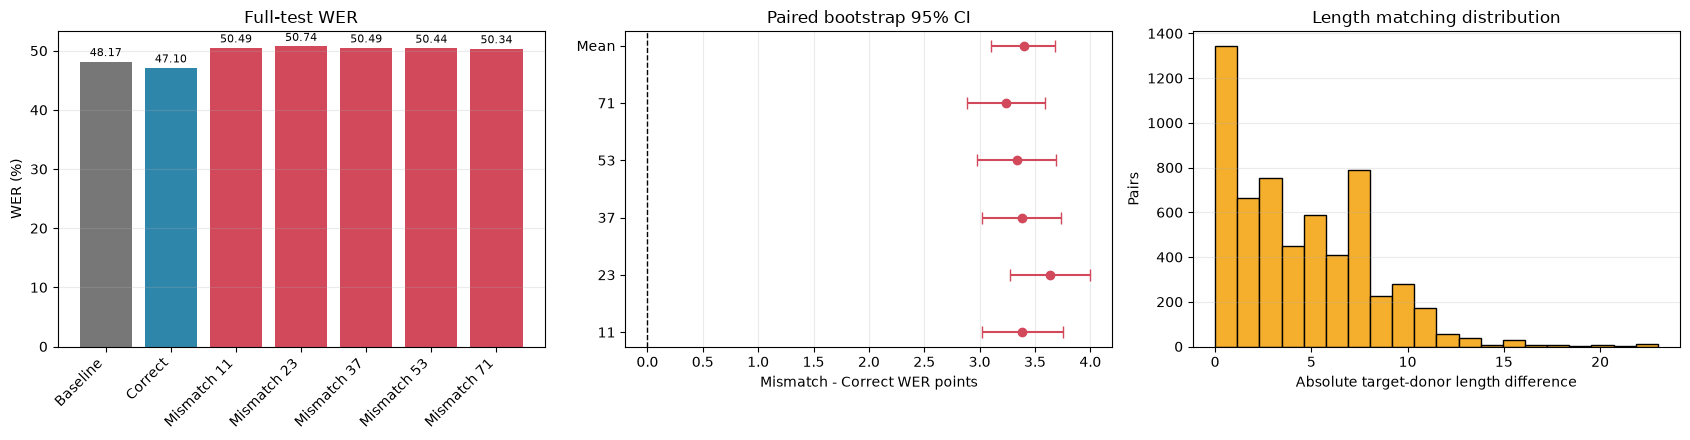

In [5]:
seed_labels = [str(seed) for seed in MISMATCH_SEEDS]
seed_wers = [incongruent_wer_values[seed] for seed in MISMATCH_SEEDS]
seed_deltas = [bootstrap_results[seed][0] for seed in MISMATCH_SEEDS]
seed_lowers = [bootstrap_results[seed][1] for seed in MISMATCH_SEEDS]
seed_uppers = [bootstrap_results[seed][2] for seed in MISMATCH_SEEDS]
all_length_differences = [
    difference
    for seed in MISMATCH_SEEDS
    for difference in length_differences[seed]
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

wer_labels = ["Baseline", "Correct", *[f"Mismatch {seed}" for seed in MISMATCH_SEEDS]]
wer_values = [baseline_wer_value, correct_wer_value, *seed_wers]
wer_colors = ["#777777", "#2E86AB", *(["#D1495B"] * len(MISMATCH_SEEDS))]
bars = axes[0].bar(range(len(wer_labels)), wer_values, color=wer_colors)
axes[0].set_xticks(range(len(wer_labels)), wer_labels, rotation=45, ha="right")
axes[0].set_ylabel("WER (%)")
axes[0].set_title("Full-test WER")
axes[0].bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
axes[0].grid(axis="y", alpha=0.25)

forest_labels = [*seed_labels, "Mean"]
forest_deltas = [*seed_deltas, mean_observed]
forest_lowers = [*seed_lowers, mean_lower]
forest_uppers = [*seed_uppers, mean_upper]
lower_errors = [
    value - lower for value, lower in zip(forest_deltas, forest_lowers)
]
upper_errors = [
    upper - value for value, upper in zip(forest_deltas, forest_uppers)
]
positions = list(range(len(forest_labels)))
axes[1].errorbar(
    forest_deltas,
    positions,
    xerr=[lower_errors, upper_errors],
    fmt="o",
    color="#D1495B",
    capsize=4,
)
axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_yticks(positions, forest_labels)
axes[1].set_xlabel("Mismatch - Correct WER points")
axes[1].set_title("Paired bootstrap 95% CI")
axes[1].grid(axis="x", alpha=0.25)

axes[2].hist(all_length_differences, bins=20, color="#F6AE2D", edgecolor="black")
axes[2].set_xlabel("Absolute target-donor length difference")
axes[2].set_ylabel("Pairs")
axes[2].set_title("Length matching distribution")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()
